# Experiment 07A — Tuned 4-crop DenseNet121 Imbalance Method Comparison

This notebook continues the experimental route after selecting:

- **HybridChenOrdinalLoss** as the ordinal-aware loss.
- **light augmentation** as the preprocessing setting.
- A clinically motivated **4-crop multi-region input**: `wide`, `center`, `left_edge`, and `right_edge`.

The purpose of this experiment is to re-check the class imbalance strategy after switching from single-image input to tuned 4-crop input.

Compared imbalance strategies:

1. **Class-weighted HybridChenOrdinalLoss**
2. **WeightedRandomSampler**
3. **Class weight + WeightedRandomSampler**

The model setting is tuned toward the previous stronger 4-crop setting:

- `IMG_SIZE = 320`
- `BATCH_SIZE = 16`
- `LR = 5e-5`
- `ORDINAL_ALPHA = 0.20`
- `DROPOUT = 0.3`
- light affine augmentation with `degrees = 5`


## 1. Imports & Environment Setup

In [3]:
from pathlib import Path
import os
import random
import json
import time
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, models, datasets

from sklearn.metrics import (
   accuracy_score,
   f1_score,
   confusion_matrix,
   classification_report,
   cohen_kappa_score,
   ConfusionMatrixDisplay
)

from PIL import Image
from tqdm import tqdm

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration Section

This section makes the experiment reproducible and easy to compare with previous experiments.

In [4]:
CONFIG = {
   "IMG_SIZE": 320,
   "BATCH_SIZE": 16,
   "EPOCHS": 30,
   "LR": 5e-5,
       "SEED": 42,
    "SEEDS": [42, 123, 2024, 3407, 777],
    "RUN_MULTI_SEED": True,
    "DETERMINISTIC": True,
   "MODEL_NAME": "Tuned 4-crop DenseNet121",
   "LOSS": "HybridChenOrdinalLoss",
   "NUM_CLASSES": 5,
   "DROPOUT": 0.3,
   "ORDINAL_ALPHA": 0.20,
   "PENALTY_DISTANCE": 2,
   "SQUARE_LOSS": False,
   "NORMALIZE_MATRIX": True,
   "WEIGHT_DECAY": 0.0,
   "PATIENCE": 7,
   "USE_AMP": True,
   "NUM_WORKERS": 0,
   "AFFINE_DEGREES": 5,
   "TRANSLATE": (0.02, 0.02),
   "SCALE": (0.97, 1.03),
   "EXPERIMENT_NAME": "exp07A_tuned_4crop_imbalance_comparison",
}

CROP_NAMES = ["wide", "center", "left_edge", "right_edge"]
NUM_CROPS = len(CROP_NAMES)

# Crop box ratios
CENTER_CROP_WIDTH_RATIO = 0.70
CENTER_CROP_HEIGHT_RATIO = 0.80
EDGE_CROP_WIDTH_RATIO = 0.55
EDGE_CROP_HEIGHT_RATIO = 0.80
LEFT_CENTER_X_RATIO = 0.30
RIGHT_CENTER_X_RATIO = 0.70
CENTER_X_RATIO = 0.50
CENTER_Y_RATIO = 0.50

OUTPUT_DIR = Path("/kaggle/working") / CONFIG["EXPERIMENT_NAME"]
RESULTS_DIR = OUTPUT_DIR / "results"
MODELS_DIR = OUTPUT_DIR / "models"
FIGURES_DIR = OUTPUT_DIR / "figures"

for p in [RESULTS_DIR, MODELS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("CONFIG:")
print(json.dumps(CONFIG, indent=2, default=str))
print("Output dir:", OUTPUT_DIR)
print("Crop names:", CROP_NAMES)


CONFIG:
{
  "IMG_SIZE": 320,
  "BATCH_SIZE": 16,
  "EPOCHS": 30,
  "LR": 5e-05,
  "SEED": 42,
  "SEEDS": [
    42,
    123,
    2024,
    3407,
    777
  ],
  "RUN_MULTI_SEED": true,
  "DETERMINISTIC": true,
  "MODEL_NAME": "Tuned 4-crop DenseNet121",
  "LOSS": "HybridChenOrdinalLoss",
  "NUM_CLASSES": 5,
  "DROPOUT": 0.3,
  "ORDINAL_ALPHA": 0.2,
  "PENALTY_DISTANCE": 2,
  "SQUARE_LOSS": false,
  "NORMALIZE_MATRIX": true,
  "WEIGHT_DECAY": 0.0,
  "PATIENCE": 7,
  "USE_AMP": true,
  "NUM_WORKERS": 0,
  "AFFINE_DEGREES": 5,
  "TRANSLATE": [
    0.02,
    0.02
  ],
  "SCALE": [
    0.97,
    1.03
  ],
  "EXPERIMENT_NAME": "exp07A_tuned_4crop_imbalance_comparison"
}
Output dir: /kaggle/working/exp07A_tuned_4crop_imbalance_comparison
Crop names: ['wide', 'center', 'left_edge', 'right_edge']


## 3. Dataset Paths

The dataset folder should contain `train`, `val`, and `test` directories.

In [5]:
# Change this path to your own dataset folder.
# The folder should contain train/, val/, and test/.
from pathlib import Path
DATA_ROOT = Path("/kaggle/input/datasets/wanqianbao/data-splits/data")

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("TEST_DIR:", TEST_DIR)

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not d.exists():
        raise FileNotFoundError(f"Missing folder: {d}")

print("Dataset paths are valid.")


DATA_ROOT: /kaggle/input/datasets/wanqianbao/data-splits/data
TRAIN_DIR: /kaggle/input/datasets/wanqianbao/data-splits/data/train
VAL_DIR: /kaggle/input/datasets/wanqianbao/data-splits/data/val
TEST_DIR: /kaggle/input/datasets/wanqianbao/data-splits/data/test
Dataset paths are valid.


## 4. Seed Fixing

In [6]:
def set_seed(seed=42, deterministic=True):
   """Fix random seeds for Python, NumPy, PyTorch, CUDA, and DataLoader reproducibility."""
   random.seed(seed)
   np.random.seed(seed)

   torch.manual_seed(seed)
   torch.cuda.manual_seed(seed)
   torch.cuda.manual_seed_all(seed)

   os.environ["PYTHONHASHSEED"] = str(seed)

   if deterministic:
      torch.backends.cudnn.benchmark = False
      torch.backends.cudnn.deterministic = True
      torch.use_deterministic_algorithms(True, warn_only=True)
   else:
      torch.backends.cudnn.benchmark = True
      torch.backends.cudnn.deterministic = False


set_seed(CONFIG["SEED"], deterministic=CONFIG["DETERMINISTIC"])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 5. Data Preprocessing

This experiment uses tuned 4-crop input with light augmentation:

- Resize each crop to `320 × 320`
- Random horizontal flip
- Random affine transformation with small rotation, translation, and scale
- Tensor conversion
- Normalization

No CLAHE is used for training in this experiment. CLAHE is only shown as a visualization preview.


In [7]:
MEAN = [0.485, 0.485, 0.485]
STD = [0.229, 0.229, 0.229]

def make_crop_box(width, height, center_x_ratio, center_y_ratio, width_ratio, height_ratio):
    crop_w = int(width * width_ratio)
    crop_h = int(height * height_ratio)

    center_x = int(width * center_x_ratio)
    center_y = int(height * center_y_ratio)

    left = max(0, center_x - crop_w // 2)
    top = max(0, center_y - crop_h // 2)
    right = min(width, left + crop_w)
    bottom = min(height, top + crop_h)

    # Adjust if the crop touches image boundary
    left = max(0, right - crop_w)
    top = max(0, bottom - crop_h)

    return (left, top, right, bottom)


class MultiCropTransform:
    """
    Convert one PIL image into multiple anatomical crops.
    The returned tensor shape is [num_crops, 3, IMG_SIZE, IMG_SIZE].
    """

    def __init__(self, crop_mode="4crop", train=True):
        self.crop_mode = crop_mode
        self.train = train

        if train:
            self.pre_crop_aug = transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomAffine(
                    degrees=CONFIG["AFFINE_DEGREES"],
                    translate=CONFIG["TRANSLATE"],
                    scale=CONFIG["SCALE"],
                    fill=0
                ),
            ])
        else:
            self.pre_crop_aug = None

        self.post_crop_transform = transforms.Compose([
            transforms.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),
            transforms.ToTensor(),
            transforms.Normalize(mean=MEAN, std=STD),
        ])

    def __call__(self, img):
        img = img.convert("RGB")

        if self.pre_crop_aug is not None:
            img = self.pre_crop_aug(img)

        w, h = img.size
        crops = []

        # 1) Wide crop: whole X-ray
        wide = img
        crops.append(wide)

        # 2) Center crop: central joint space
        center_box = make_crop_box(
            width=w,
            height=h,
            center_x_ratio=CENTER_X_RATIO,
            center_y_ratio=CENTER_Y_RATIO,
            width_ratio=CENTER_CROP_WIDTH_RATIO,
            height_ratio=CENTER_CROP_HEIGHT_RATIO,
        )
        center = img.crop(center_box)

        # 3) Left edge crop
        left_box = make_crop_box(
            width=w,
            height=h,
            center_x_ratio=LEFT_CENTER_X_RATIO,
            center_y_ratio=CENTER_Y_RATIO,
            width_ratio=EDGE_CROP_WIDTH_RATIO,
            height_ratio=EDGE_CROP_HEIGHT_RATIO,
        )
        left_edge = img.crop(left_box)

        # 4) Right edge crop
        right_box = make_crop_box(
            width=w,
            height=h,
            center_x_ratio=RIGHT_CENTER_X_RATIO,
            center_y_ratio=CENTER_Y_RATIO,
            width_ratio=EDGE_CROP_WIDTH_RATIO,
            height_ratio=EDGE_CROP_HEIGHT_RATIO,
        )
        right_edge = img.crop(right_box)

        crops = [wide, center, left_edge, right_edge]

        crop_tensors = [self.post_crop_transform(crop) for crop in crops]
        return torch.stack(crop_tensors, dim=0)


train_transform = MultiCropTransform(crop_mode="4crop", train=True)
valid_transform = MultiCropTransform(crop_mode="4crop", train=False)

raw_transform = None

print("Train transform: 4-crop + light augmentation")
print("Valid/test transform: 4-crop deterministic preprocessing")


Train transform: 4-crop + light augmentation
Valid/test transform: 4-crop deterministic preprocessing


## 6. Dataset & Dataloader

This section prints the train/validation/test sizes and the class distribution. It also prepares different DataLoader settings for different imbalance methods.


In [8]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=valid_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=valid_transform)

raw_train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=None)
raw_test_dataset = datasets.ImageFolder(TEST_DIR, transform=None)

class_names = train_dataset.classes
class_to_idx = train_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

print("Number of train images:", len(train_dataset))
print("Number of val images:", len(val_dataset))
print("Number of test images:", len(test_dataset))
print("Class to idx:", class_to_idx)

def get_targets(dataset):
    if hasattr(dataset, "targets"):
        return np.array(dataset.targets)
    return np.array([label for _, label in dataset.samples])

train_targets = get_targets(train_dataset)
val_targets = get_targets(val_dataset)
test_targets = get_targets(test_dataset)

def distribution_df(targets, split_name):
    counts = np.bincount(targets, minlength=CONFIG["NUM_CLASSES"])
    return pd.DataFrame({
        "split": split_name,
        "class_idx": list(range(CONFIG["NUM_CLASSES"])),
        "class_name": class_names,
        "count": counts,
        "percentage": counts / counts.sum()
    })

dist_df = pd.concat([
    distribution_df(train_targets, "train"),
    distribution_df(val_targets, "val"),
    distribution_df(test_targets, "test"),
], ignore_index=True)

display(dist_df)

train_class_counts = np.bincount(train_targets, minlength=CONFIG["NUM_CLASSES"])
class_weights_np = len(train_targets) / (CONFIG["NUM_CLASSES"] * train_class_counts)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

print("Train class counts:", dict(zip(class_names, train_class_counts)))
print("Class weights:", dict(zip(class_names, class_weights_np.round(4))))

def seed_worker(worker_id):
    """Make DataLoader workers reproducible."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def make_weighted_sampler(targets, seed=42):
    class_counts = np.bincount(targets, minlength=CONFIG["NUM_CLASSES"])
    class_sample_weights = 1.0 / class_counts
    sample_weights = class_sample_weights[targets]
    sample_weights = torch.DoubleTensor(sample_weights)

    g = torch.Generator()
    g.manual_seed(seed)

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(targets),
        replacement=True,
        generator=g
    )
    return sampler


weighted_sampler = make_weighted_sampler(train_targets, seed=CONFIG["SEED"])

# Show sampled distribution for one epoch
sampled_indices = list(iter(weighted_sampler))
sampled_targets = train_targets[sampled_indices]
sampled_counts = np.bincount(sampled_targets, minlength=CONFIG["NUM_CLASSES"])

sampler_check_df = pd.DataFrame({
    "class_name": class_names,
    "original_count": train_class_counts,
    "weighted_sampler_count_one_epoch": sampled_counts,
})
display(sampler_check_df)


def build_loaders(use_sampler=False, seed=42):
    g = torch.Generator()
    g.manual_seed(seed)

    if use_sampler:
        local_weighted_sampler = make_weighted_sampler(train_targets, seed=seed)

        train_loader = DataLoader(
            train_dataset,
            batch_size=CONFIG["BATCH_SIZE"],
            sampler=local_weighted_sampler,
            shuffle=False,
            num_workers=CONFIG["NUM_WORKERS"],
            pin_memory=torch.cuda.is_available(),
            worker_init_fn=seed_worker,
            generator=g,
        )
    else:
        train_loader = DataLoader(
            train_dataset,
            batch_size=CONFIG["BATCH_SIZE"],
            shuffle=True,
            num_workers=CONFIG["NUM_WORKERS"],
            pin_memory=torch.cuda.is_available(),
            worker_init_fn=seed_worker,
            generator=g,
        )

    val_loader = DataLoader(
        val_dataset,
        batch_size=CONFIG["BATCH_SIZE"],
        shuffle=False,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=CONFIG["BATCH_SIZE"],
        shuffle=False,
        num_workers=CONFIG["NUM_WORKERS"],
        pin_memory=torch.cuda.is_available(),
        worker_init_fn=seed_worker,
    )

    return train_loader, val_loader, test_loader


Number of train images: 1024
Number of val images: 146
Number of test images: 294
Class to idx: {'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}


,split,class_idx,class_name,count,percentage
0,train,0,0Normal,316,0.308594
1,train,1,1Doubtful,308,0.300781
2,train,2,2Mild,134,0.130859
3,train,3,3Moderate,122,0.119141
4,train,4,4Severe,144,0.140625
5,val,0,0Normal,45,0.308219
6,val,1,1Doubtful,44,0.301370
7,val,2,2Mild,19,0.130137
8,val,3,3Moderate,18,0.123288
9,val,4,4Severe,20,0.136986


Train class counts: {'0Normal': np.int64(316), '1Doubtful': np.int64(308), '2Mild': np.int64(134), '3Moderate': np.int64(122), '4Severe': np.int64(144)}
Class weights: {'0Normal': np.float64(0.6481), '1Doubtful': np.float64(0.6649), '2Mild': np.float64(1.5284), '3Moderate': np.float64(1.6787), '4Severe': np.float64(1.4222)}


,class_name,original_count,weighted_sampler_count_one_epoch
0,0Normal,316,215
1,1Doubtful,308,210
2,2Mild,134,211
3,3Moderate,122,199
4,4Severe,144,189


## 7. Visualization

This section shows:

1. Original raw X-ray image.
2. Transformed 4-crop tensor after denormalization.
3. CLAHE preview only.
4. 4-crop anatomical regions: wide, center, left edge, and right edge.


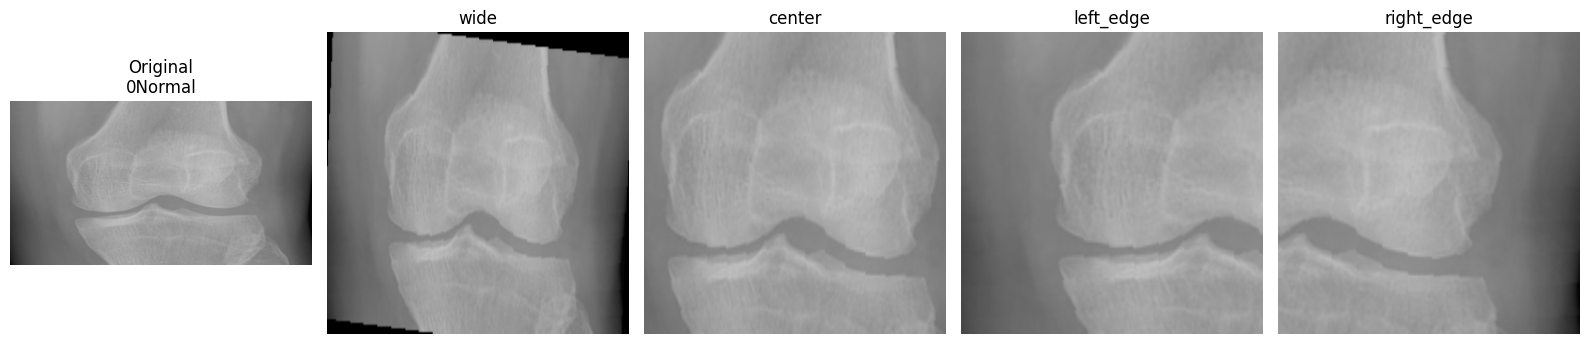

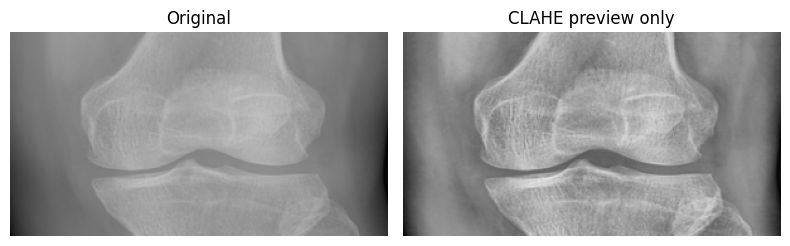

In [9]:
def denormalize_tensor(img_tensor, mean=MEAN, std=STD):
    img = img_tensor.detach().cpu().clone()
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    img = img * std_t + mean_t
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

def show_raw_and_4crop_sample(dataset, raw_dataset, sample_idx=0):
    raw_path, raw_label = raw_dataset.samples[sample_idx]
    raw_img = Image.open(raw_path).convert("L")

    crops, label = dataset[sample_idx]

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 5, 1)
    plt.imshow(raw_img, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Original\n{class_names[label]}")
    plt.axis("off")

    for i in range(NUM_CROPS):
        plt.subplot(1, 5, i + 2)
        plt.imshow(denormalize_tensor(crops[i]))
        plt.title(CROP_NAMES[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_raw_and_4crop_sample(train_dataset, raw_train_dataset, sample_idx=0)

def show_clahe_preview(raw_dataset, sample_idx=0):
    img_path, label = raw_dataset.samples[sample_idx]
    img = Image.open(img_path).convert("L")
    arr = np.array(img)

    try:
        import cv2
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        clahe_arr = clahe.apply(arr)
    except Exception:
        # Fallback if cv2 is unavailable
        from PIL import ImageOps
        clahe_arr = np.array(ImageOps.equalize(img))

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(arr, cmap="gray", vmin=0, vmax=255)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(clahe_arr, cmap="gray", vmin=0, vmax=255)
    plt.title("CLAHE preview only")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_clahe_preview(raw_train_dataset, sample_idx=0)


## 8. Model Definition

The model receives four anatomical crops per X-ray:

- `wide`: whole knee X-ray / overall joint structure
- `center`: central joint space
- `left_edge`: left joint edge
- `right_edge`: right joint edge

Each crop is passed through the same DenseNet121 backbone. Crop features are averaged and then classified.


In [10]:
class MultiCropDenseNet121(nn.Module):
    def __init__(self, num_classes=5, dropout=0.3):
        super().__init__()

        self.backbone = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, crops):
        # crops shape: [B, N, C, H, W]
        b, n, c, h, w = crops.shape
        x = crops.view(b * n, c, h, w)

        features = self.backbone(x)      # [B*N, F]
        features = features.view(b, n, -1)

        fused = features.mean(dim=1)     # mean fusion across crops
        logits = self.classifier(fused)

        return logits

def build_model():
    model = MultiCropDenseNet121(
        num_classes=CONFIG["NUM_CLASSES"],
        dropout=CONFIG["DROPOUT"]
    )
    return model.to(device)

model_check = build_model()
dummy = torch.randn(2, NUM_CROPS, 3, CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"]).to(device)
with torch.no_grad():
    out = model_check(dummy)
print("Dummy output shape:", out.shape)
del model_check, dummy, out
torch.cuda.empty_cache()


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 201MB/s]


Dummy output shape: torch.Size([2, 5])


## 9. Loss Function

This experiment uses **HybridChenOrdinalLoss**. The loss combines:

- CrossEntropyLoss for normal 5-class learning.
- Chen-style ordinal penalty to discourage large KL-grade mistakes.

For imbalance comparison, this notebook tests:

1. Class-weighted HybridChenOrdinalLoss.
2. HybridChenOrdinalLoss with WeightedRandomSampler.
3. Class-weighted HybridChenOrdinalLoss with WeightedRandomSampler.


In [11]:
class HybridChenOrdinalLoss(nn.Module):
    def __init__(
        self,
        num_classes=5,
        alpha=0.20,
        penalty_distance=2,
        square_loss=False,
        normalize=True,
        class_weights=None
    ):
        super().__init__()

        self.num_classes = num_classes
        self.alpha = alpha
        self.penalty_distance = penalty_distance
        self.square_loss = square_loss
        self.normalize = normalize
        self.class_weights = class_weights

        penalty_matrix = self._create_penalty_matrix(
            num_classes=num_classes,
            penalty_distance=penalty_distance,
            normalize=normalize
        )

        self.register_buffer("penalty_matrix", penalty_matrix)

    def _create_penalty_matrix(self, num_classes, penalty_distance, normalize):
        class_indices = torch.arange(num_classes, dtype=torch.float32)

        distance_matrix = torch.abs(
            class_indices.unsqueeze(0) - class_indices.unsqueeze(1)
        )

        penalty_matrix = distance_matrix * penalty_distance + 1.0
        penalty_matrix[distance_matrix == 0] = 0.0

        if normalize:
            max_value = penalty_matrix.max()
            if max_value > 0:
                penalty_matrix = penalty_matrix / max_value

        return penalty_matrix

    def forward(self, logits, targets, return_parts=False):
        ce = F.cross_entropy(
            logits,
            targets,
            weight=self.class_weights
        )

        probabilities = F.softmax(logits, dim=1)
        penalty_matrix = self.penalty_matrix.to(logits.device)
        targets = targets.long()

        target_penalties = penalty_matrix[targets]
        penalty_per_sample = torch.sum(
            probabilities * target_penalties,
            dim=1
        )

        if self.square_loss:
            penalty_per_sample = penalty_per_sample ** 2

        ordinal_penalty = torch.mean(penalty_per_sample)
        weighted_ordinal_penalty = self.alpha * ordinal_penalty

        total_loss = ce + weighted_ordinal_penalty

        if return_parts:
            return total_loss, ce, ordinal_penalty, weighted_ordinal_penalty

        return total_loss

criterion_check = HybridChenOrdinalLoss(
    num_classes=CONFIG["NUM_CLASSES"],
    alpha=CONFIG["ORDINAL_ALPHA"],
    penalty_distance=CONFIG["PENALTY_DISTANCE"],
    square_loss=CONFIG["SQUARE_LOSS"],
    normalize=CONFIG["NORMALIZE_MATRIX"],
    class_weights=None
).to(device)

print("Hybrid Chen loss formula:")
print(f"total_loss = CrossEntropyLoss + {CONFIG['ORDINAL_ALPHA']} * ChenOrdinalPenalty")
print("\nChen-style penalty matrix:")
print(criterion_check.penalty_matrix.detach().cpu().numpy())

print("\nClass weights used in class-weighted experiments:")
for cls, weight in zip(class_names, class_weights_np):
    print(f"{cls}: {weight:.4f}")


Hybrid Chen loss formula:
total_loss = CrossEntropyLoss + 0.2 * ChenOrdinalPenalty

Chen-style penalty matrix:
[[0.         0.33333334 0.5555556  0.7777778  1.        ]
 [0.33333334 0.         0.33333334 0.5555556  0.7777778 ]
 [0.5555556  0.33333334 0.         0.33333334 0.5555556 ]
 [0.7777778  0.5555556  0.33333334 0.         0.33333334]
 [1.         0.7777778  0.5555556  0.33333334 0.        ]]

Class weights used in class-weighted experiments:
0Normal: 0.6481
1Doubtful: 0.6649
2Mild: 1.5284
3Moderate: 1.6787
4Severe: 1.4222


## 10. Optimizer & Scheduler

In [12]:
def build_optimizer_and_scheduler(model):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG["LR"],
        weight_decay=CONFIG["WEIGHT_DECAY"]
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=CONFIG["EPOCHS"]
    )

    return optimizer, scheduler


## 11. Training Loop

The loop records:

- train loss
- validation loss
- validation accuracy
- validation macro F1
- validation QWK
- validation MAE
- validation adjacent/distant errors


In [13]:
def compute_metrics(y_true, y_pred, loss=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    diff = np.abs(y_true - y_pred)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "qwk": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
        "mae": float(np.mean(diff)),
        "total_errors": int(np.sum(diff != 0)),
        "adjacent_errors": int(np.sum(diff == 1)),
        "distant_errors": int(np.sum(diff >= 2)),
    }

    if loss is not None:
        metrics["loss"] = float(loss)

    return metrics

def train_one_epoch(model, loader, criterion, optimizer, scaler=None, desc="train"):
    model.train()

    running_loss = 0.0
    running_ce = 0.0
    running_ord = 0.0
    all_true = []
    all_pred = []

    use_amp = CONFIG["USE_AMP"] and device.type == "cuda"

    for crops, labels in tqdm(loader, desc=desc, leave=False):
        crops = crops.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            autocast_context = torch.amp.autocast("cuda", enabled=True)
        else:
            autocast_context = nullcontext()

        with autocast_context:
            logits = model(crops)
            loss, ce_loss, ord_loss, weighted_ord = criterion(
                logits,
                labels,
                return_parts=True
            )

        if scaler is not None and use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_ce += ce_loss.item() * batch_size
        running_ord += ord_loss.item() * batch_size

        preds = torch.argmax(logits.detach(), dim=1)
        all_true.extend(labels.detach().cpu().numpy().tolist())
        all_pred.extend(preds.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_true, all_pred, loss=epoch_loss)
    metrics["ce_loss"] = running_ce / len(loader.dataset)
    metrics["ordinal_penalty"] = running_ord / len(loader.dataset)

    return metrics


## 12. Validation Section

Validation is performed with `model.eval()` and reports accuracy, macro F1, QWK, MAE, and ordinal error distances.


In [14]:
@torch.no_grad()
def evaluate(model, loader, criterion, desc="eval"):
    model.eval()

    running_loss = 0.0
    all_true = []
    all_pred = []

    for crops, labels in tqdm(loader, desc=desc, leave=False):
        crops = crops.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(crops)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)
        all_true.extend(labels.detach().cpu().numpy().tolist())
        all_pred.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_true, all_pred, loss=avg_loss)

    return metrics, all_true, all_pred


## 13. Test Evaluation

This section runs all imbalance comparison experiments and evaluates each model on the test set.


In [15]:
IMBALANCE_EXPERIMENTS = [
    {
        "name": "class_weight",
        "use_class_weights": True,
        "use_sampler": False,
        "description": "Class-weighted HybridChenOrdinalLoss"
    },
    {
        "name": "weighted_random_sampler",
        "use_class_weights": False,
        "use_sampler": True,
        "description": "HybridChenOrdinalLoss + WeightedRandomSampler"
    },
    {
        "name": "class_weight_plus_sampler",
        "use_class_weights": True,
        "use_sampler": True,
        "description": "Class-weighted HybridChenOrdinalLoss + WeightedRandomSampler"
    },
]


def run_one_imbalance_experiment(exp_cfg, seed=42):
    name = exp_cfg["name"]

    print("\n" + "=" * 100)
    print(f"Experiment: {name} | seed = {seed}")
    print("=" * 100)

    set_seed(seed, deterministic=CONFIG["DETERMINISTIC"])

    train_loader, val_loader, test_loader = build_loaders(
        use_sampler=exp_cfg["use_sampler"],
        seed=seed
    )

    model = build_model()
    model = model.to(device)

    criterion = HybridChenOrdinalLoss(
        num_classes=CONFIG["NUM_CLASSES"],
        alpha=CONFIG["ORDINAL_ALPHA"],
        penalty_distance=CONFIG["PENALTY_DISTANCE"],
        square_loss=CONFIG["SQUARE_LOSS"],
        normalize=CONFIG["NORMALIZE_MATRIX"],
        class_weights=class_weights_tensor if exp_cfg["use_class_weights"] else None
    ).to(device)

    print("Penalty matrix for", name)
    print(criterion.penalty_matrix.detach().cpu().numpy())

    optimizer, scheduler = build_optimizer_and_scheduler(model)

    use_amp = CONFIG["USE_AMP"] and device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp) if device.type == "cuda" else None

    best_val_qwk = -999
    best_epoch = -1
    no_improve = 0
    history = []

    best_path = MODELS_DIR / f"{name}_seed{seed}_best_state_dict.pth"

    for epoch in range(1, CONFIG["EPOCHS"] + 1):
        print(f"\nEpoch {epoch}/{CONFIG['EPOCHS']} | {name} | seed={seed}")

        train_metrics = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            scaler=scaler,
            desc=f"{name} seed{seed} train"
        )

        val_metrics, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            desc=f"{name} seed{seed} val"
        )

        scheduler.step()

        row = {
            "experiment": name,
            "seed": seed,
            "epoch": epoch,
            **{f"train_{k}": v for k, v in train_metrics.items()},
            **{f"val_{k}": v for k, v in val_metrics.items()},
        }
        history.append(row)

        print(
            f"train_loss={train_metrics['loss']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_macro_f1={val_metrics['macro_f1']:.4f} | "
            f"val_qwk={val_metrics['qwk']:.4f} | "
            f"val_mae={val_metrics['mae']:.4f} | "
            f"val_distant={val_metrics['distant_errors']}"
        )

        if val_metrics["qwk"] > best_val_qwk:
            best_val_qwk = val_metrics["qwk"]
            best_epoch = epoch
            no_improve = 0

            torch.save(model.state_dict(), best_path)

            print(f"New best val QWK: {best_val_qwk:.4f}")
        else:
            no_improve += 1
            print(f"No improvement: {no_improve}/{CONFIG['PATIENCE']}")

        if no_improve >= CONFIG["PATIENCE"]:
            print("Early stopping triggered.")
            break

    history_df = pd.DataFrame(history)

    history_df.to_csv(
        RESULTS_DIR / f"history_{name}_seed{seed}.csv",
        index=False
    )

    state_dict = torch.load(best_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)

    test_metrics, test_true, test_pred = evaluate(
        model,
        test_loader,
        criterion,
        desc=f"{name} seed{seed} test"
    )

    print("\nTest results for:", name, "| seed =", seed)
    for k, v in test_metrics.items():
        print(f"{k}: {v}")

    result = {
        "experiment": name,
        "seed": seed,
        "description": exp_cfg["description"],
        "use_class_weights": exp_cfg["use_class_weights"],
        "use_sampler": exp_cfg["use_sampler"],
        "best_epoch": best_epoch,
        "best_val_qwk": best_val_qwk,
        "model_path": str(best_path),
        **{f"test_{k}": v for k, v in test_metrics.items()}
    }

    with open(RESULTS_DIR / f"metrics_{name}_seed{seed}.json", "w") as f:
        json.dump(result, f, indent=2)

    del model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result, history_df, test_true, test_pred


all_results = []
all_histories = {}
all_predictions = {}

if CONFIG.get("RUN_MULTI_SEED", True):
    run_seeds = CONFIG["SEEDS"]
else:
    run_seeds = [CONFIG["SEED"]]

for seed in run_seeds:
    print("\n" + "#" * 100)
    print(f"Running imbalance experiments with seed = {seed}")
    print("#" * 100)

    for exp_cfg in IMBALANCE_EXPERIMENTS:
        result, history_df, test_true, test_pred = run_one_imbalance_experiment(
            exp_cfg,
            seed=seed
        )

        exp_name = exp_cfg["name"]
        key = f"{exp_name}_seed{seed}"

        all_results.append(result)
        all_histories[key] = history_df
        all_predictions[key] = {
            "test_true": test_true,
            "test_pred": test_pred,
            "seed": seed,
            "experiment": exp_name,
        }

results_df = pd.DataFrame(all_results)

results_df.to_csv(
    RESULTS_DIR / "imbalance_comparison_results_multiseed.csv",
    index=False
)

display(results_df.sort_values(["experiment", "seed"]))



####################################################################################################
Running imbalance experiments with seed = 42
####################################################################################################

Experiment: class_weight | seed = 42
Penalty matrix for class_weight
[[0.         0.33333334 0.5555556  0.7777778  1.        ]
 [0.33333334 0.         0.33333334 0.5555556  0.7777778 ]
 [0.5555556  0.33333334 0.         0.33333334 0.5555556 ]
 [0.7777778  0.5555556  0.33333334 0.         0.33333334]
 [1.         0.7777778  0.5555556  0.33333334 0.        ]]

Epoch 1/30 | class_weight | seed=42


train_loss=1.4227 | val_loss=1.0434 | val_acc=0.6712 | val_macro_f1=0.6236 | val_qwk=0.8314 | val_mae=0.4452 | val_distant=14
New best val QWK: 0.8314

Epoch 2/30 | class_weight | seed=42


train_loss=0.9637 | val_loss=0.8075 | val_acc=0.6918 | val_macro_f1=0.6842 | val_qwk=0.8571 | val_mae=0.3904 | val_distant=10
New best val QWK: 0.8571

Epoch 3/30 | class_weight | seed=42


train_loss=0.7804 | val_loss=0.6464 | val_acc=0.7945 | val_macro_f1=0.7855 | val_qwk=0.8939 | val_mae=0.2671 | val_distant=7
New best val QWK: 0.8939

Epoch 4/30 | class_weight | seed=42


train_loss=0.6377 | val_loss=0.5990 | val_acc=0.7877 | val_macro_f1=0.7780 | val_qwk=0.8873 | val_mae=0.2740 | val_distant=6
No improvement: 1/7

Epoch 5/30 | class_weight | seed=42


...

train_loss=0.1040 | val_loss=0.3657 | val_acc=0.8767 | val_macro_f1=0.8846 | val_qwk=0.9269 | val_mae=0.1644 | val_distant=3
No improvement: 5/7

Epoch 25/30 | class_weight_plus_sampler | seed=777


train_loss=0.0918 | val_loss=0.3537 | val_acc=0.8836 | val_macro_f1=0.8868 | val_qwk=0.9239 | val_mae=0.1644 | val_distant=4
No improvement: 6/7

Epoch 26/30 | class_weight_plus_sampler | seed=777


train_loss=0.1005 | val_loss=0.3375 | val_acc=0.8767 | val_macro_f1=0.8852 | val_qwk=0.9404 | val_mae=0.1507 | val_distant=2
No improvement: 7/7
Early stopping triggered.



Test results for: class_weight_plus_sampler | seed = 777
accuracy: 0.8401360544217688
macro_f1: 0.8398540046417635
weighted_f1: 0.8407688070444495
qwk: 0.9068632018336656
mae: 0.2108843537414966
total_errors: 47
adjacent_errors: 37
distant_errors: 10
loss: 0.4834644165662985


,experiment,seed,description,use_class_weights,use_sampler,best_epoch,best_val_qwk,model_path,test_accuracy,test_macro_f1,test_weighted_f1,test_qwk,test_mae,test_total_errors,test_adjacent_errors,test_distant_errors,test_loss
0,class_weight,42,Class-weighted HybridChenOrdinalLoss,True,False,10,0.958654,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.836735,0.837593,0.837254,0.889345,0.231293,48,36,12,0.484250
3,class_weight,123,Class-weighted HybridChenOrdinalLoss,True,False,20,0.975043,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.840136,0.834930,0.840930,0.911260,0.210884,47,36,11,0.484753
12,class_weight,777,Class-weighted HybridChenOrdinalLoss,True,False,14,0.961858,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.840136,0.831317,0.840126,0.901484,0.217687,47,36,11,0.414003
6,class_weight,2024,Class-weighted HybridChenOrdinalLoss,True,False,20,0.956370,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.846939,0.853676,0.846876,0.892075,0.224490,45,31,14,0.457828
9,class_weight,3407,Class-weighted HybridChenOrdinalLoss,True,False,21,0.957494,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.867347,0.869513,0.867550,0.919803,0.180272,39,30,9,0.434730
2,class_weight_plus_sampler,42,Class-weighted HybridChenOrdinalLoss + Weighte...,True,True,14,0.964091,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.826531,0.828830,0.829133,0.889691,0.241497,51,36,15,0.484865
5,class_weight_plus_sampler,123,Class-weighted HybridChenOrdinalLoss + Weighte...,True,True,29,0.973530,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.843537,0.845461,0.844462,0.906794,0.214286,46,33,13,0.498875
14,class_weight_plus_sampler,777,Class-weighted HybridChenOrdinalLoss + Weighte...,True,True,19,0.949341,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.840136,0.839854,0.840769,0.906863,0.210884,47,37,10,0.483464
8,class_weight_plus_sampler,2024,Class-weighted HybridChenOrdinalLoss + Weighte...,True,True,13,0.945722,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.860544,0.859376,0.861878,0.896732,0.207483,41,28,13,0.429470
11,class_weight_plus_sampler,3407,Class-weighted HybridChenOrdinalLoss + Weighte...,True,True,14,0.963600,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.843537,0.849249,0.845030,0.890582,0.231293,46,30,16,0.453092


In [16]:
metric_cols = [
    "test_accuracy",
    "test_macro_f1",
    "test_weighted_f1",
    "test_qwk",
    "test_mae",
    "test_total_errors",
    "test_adjacent_errors",
    "test_distant_errors",
]

summary_rows = []

for exp_name in results_df["experiment"].unique():
    exp_df = results_df[results_df["experiment"] == exp_name]

    for metric in metric_cols:
        values = exp_df[metric].astype(float)

        summary_rows.append({
            "experiment": exp_name,
            "metric": metric,
            "mean": float(values.mean()),
            "std": float(values.std(ddof=0)),
            "min": float(values.min()),
            "max": float(values.max()),
            "mean±std": f"{values.mean():.4f} ± {values.std(ddof=0):.4f}",
        })

multi_seed_summary_df = pd.DataFrame(summary_rows)

multi_seed_summary_df.to_csv(
    RESULTS_DIR / "imbalance_comparison_multiseed_summary.csv",
    index=False
)

display(multi_seed_summary_df)

,experiment,metric,mean,std,min,max,mean±std
0,class_weight,test_accuracy,0.846259,0.011053,0.836735,0.867347,0.8463 ± 0.0111
1,class_weight,test_macro_f1,0.845406,0.014275,0.831317,0.869513,0.8454 ± 0.0143
2,class_weight,test_weighted_f1,0.846547,0.010958,0.837254,0.867550,0.8465 ± 0.0110
3,class_weight,test_qwk,0.902793,0.011476,0.889345,0.919803,0.9028 ± 0.0115
4,class_weight,test_mae,0.212925,0.017687,0.180272,0.231293,0.2129 ± 0.0177
5,class_weight,test_total_errors,45.200000,3.249615,39.000000,48.000000,45.2000 ± 3.2496
6,class_weight,test_adjacent_errors,33.800000,2.712932,30.000000,36.000000,33.8000 ± 2.7129
7,class_weight,test_distant_errors,11.400000,1.624808,9.000000,14.000000,11.4000 ± 1.6248
8,weighted_random_sampler,test_accuracy,0.842857,0.009952,0.826531,0.853741,0.8429 ± 0.0100
9,weighted_random_sampler,test_macro_f1,0.841083,0.008926,0.827653,0.853793,0.8411 ± 0.0089


## 13.1 Per-class Recall and F1

Class-wise recall and F1 are important for medical classification because the model may perform differently across OA severity grades.


In [17]:
def classwise_report_df(y_true, y_pred, experiment_name):
    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    rows = []
    for cls in class_names:
        rows.append({
            "experiment": experiment_name,
            "class_name": cls,
            "precision": report[cls]["precision"],
            "recall": report[cls]["recall"],
            "f1_score": report[cls]["f1-score"],
            "support": report[cls]["support"],
        })

    return pd.DataFrame(rows)

classwise_dfs = []
for exp_name, pred_pack in all_predictions.items():
    df = classwise_report_df(
        pred_pack["test_true"],
        pred_pack["test_pred"],
        exp_name
    )
    classwise_dfs.append(df)

classwise_df = pd.concat(classwise_dfs, ignore_index=True)
classwise_df.to_csv(RESULTS_DIR / "classwise_recall_f1_comparison.csv", index=False)

display(classwise_df)


,experiment,class_name,precision,recall,f1_score,support
0,class_weight_seed42,0Normal,0.869565,0.879121,0.874317,91.0
1,class_weight_seed42,1Doubtful,0.795455,0.795455,0.795455,88.0
2,class_weight_seed42,2Mild,0.725000,0.763158,0.743590,38.0
3,class_weight_seed42,3Moderate,0.885714,0.885714,0.885714,35.0
4,class_weight_seed42,4Severe,0.923077,0.857143,0.888889,42.0
...,...,...,...,...,...,...
70,class_weight_plus_sampler_seed777,0Normal,0.934211,0.780220,0.850299,91.0
71,class_weight_plus_sampler_seed777,1Doubtful,0.787879,0.886364,0.834225,88.0
72,class_weight_plus_sampler_seed777,2Mild,0.755556,0.894737,0.819277,38.0
73,class_weight_plus_sampler_seed777,3Moderate,0.815789,0.885714,0.849315,35.0


## 14. Confusion Matrix

The selected model is chosen by highest validation QWK to avoid selecting based on the test set.


Selected imbalance method by validation QWK: class_weight
Best val QWK: 0.9750427350427351
Test QWK: 0.9112602850536966


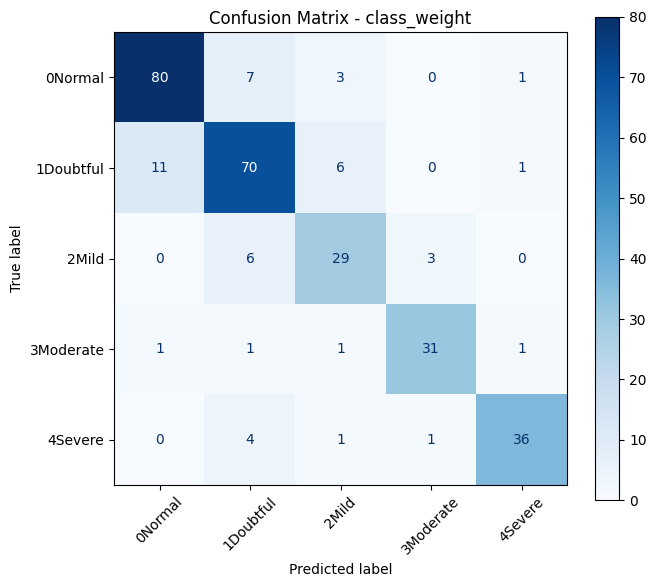

In [20]:
best_result = results_df.sort_values("best_val_qwk", ascending=False).iloc[0].to_dict()
best_name = best_result["experiment"]

print("Selected imbalance method by validation QWK:", best_name)
print("Best val QWK:", best_result["best_val_qwk"])
print("Test QWK:", best_result["test_qwk"])

# Because best_name is "class_weight",
# but predictions were saved as "class_weight_seed42"
pred_key = "class_weight_seed42"

best_true = all_predictions[pred_key]["test_true"]
best_pred = all_predictions[pred_key]["test_pred"]

cm = confusion_matrix(best_true, best_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
plt.title(f"Confusion Matrix - {best_name}")
plt.tight_layout()
plt.show()

fig.savefig(FIGURES_DIR / f"confusion_matrix_{best_name}.png", dpi=200, bbox_inches="tight")

## 15. Error Analysis

Adjacent errors and distant errors are reported because knee OA severity grading is ordinal:

`0Normal < 1Doubtful < 2Mild < 3Moderate < 4Severe`


,experiment,total,correct,total_errors,adjacent_errors,distant_errors,distance_0,distance_1,distance_2,distance_3,distance_4
0,class_weight_seed42,294,246,48,36,12,246,36,5,6,1
1,weighted_random_sampler_seed42,294,250,44,31,13,250,31,9,4,0
2,class_weight_plus_sampler_seed42,294,243,51,36,15,243,36,10,5,0
3,class_weight_seed123,294,247,47,36,11,247,36,7,4,0
4,weighted_random_sampler_seed123,294,243,51,40,11,243,40,8,3,0
5,class_weight_plus_sampler_seed123,294,248,46,33,13,248,33,9,4,0
6,class_weight_seed2024,294,249,45,31,14,249,31,8,5,1
7,weighted_random_sampler_seed2024,294,249,45,27,18,249,27,11,7,0
8,class_weight_plus_sampler_seed2024,294,253,41,28,13,253,28,7,5,1
9,class_weight_seed3407,294,255,39,30,9,255,30,4,5,0


wrong samples: 48 / 294


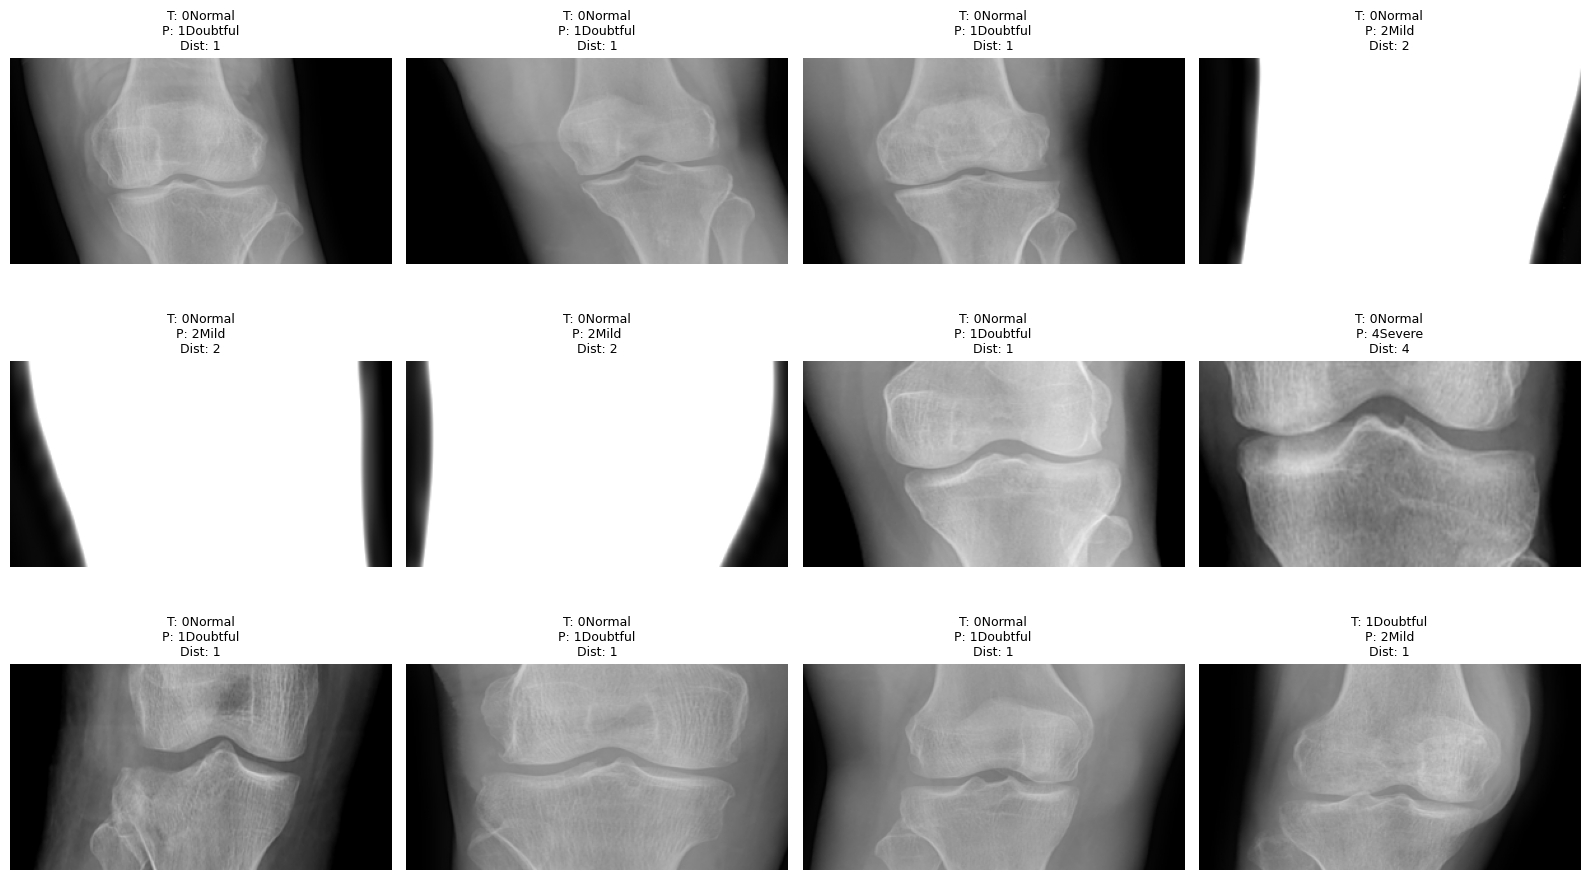

In [21]:
error_rows = []

for exp_name, pred_pack in all_predictions.items():
    y_true = np.array(pred_pack["test_true"])
    y_pred = np.array(pred_pack["test_pred"])
    diff = np.abs(y_true - y_pred)

    error_rows.append({
        "experiment": exp_name,
        "total": len(y_true),
        "correct": int(np.sum(diff == 0)),
        "total_errors": int(np.sum(diff != 0)),
        "adjacent_errors": int(np.sum(diff == 1)),
        "distant_errors": int(np.sum(diff >= 2)),
        "distance_0": int(np.sum(diff == 0)),
        "distance_1": int(np.sum(diff == 1)),
        "distance_2": int(np.sum(diff == 2)),
        "distance_3": int(np.sum(diff == 3)),
        "distance_4": int(np.sum(diff == 4)),
    })

error_df = pd.DataFrame(error_rows)
error_df.to_csv(RESULTS_DIR / "error_analysis_comparison.csv", index=False)

display(error_df)

def show_misclassified_raw_images(raw_dataset, y_true, y_pred, max_images=12):
    wrong_indices = [
        i for i, (t, p) in enumerate(zip(y_true, y_pred))
        if int(t) != int(p)
    ]

    print(f"wrong samples: {len(wrong_indices)} / {len(y_true)}")
    show_indices = wrong_indices[:max_images]

    cols = 4
    rows = int(np.ceil(len(show_indices) / cols))

    plt.figure(figsize=(cols * 4, max(1, rows) * 3.2))

    for plot_i, idx in enumerate(show_indices, start=1):
        img_path, _ = raw_dataset.samples[idx]
        true_label = int(y_true[idx])
        pred_label = int(y_pred[idx])
        dist = abs(true_label - pred_label)

        img = Image.open(img_path).convert("L")

        plt.subplot(rows, cols, plot_i)
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
        plt.axis("off")
        plt.title(
            f"T: {class_names[true_label]}\nP: {class_names[pred_label]}\nDist: {dist}",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

show_misclassified_raw_images(
    raw_dataset=raw_test_dataset,
    y_true=best_true,
    y_pred=best_pred,
    max_images=12
)


## 16. Grad-CAM

Grad-CAM is shown for one correct and one incorrect prediction from the selected model.

For multi-crop input, Grad-CAM can be generated for each crop. This notebook shows Grad-CAM on the **wide crop** by default, because it is the most comparable to the original X-ray view.


Correct example index: 0


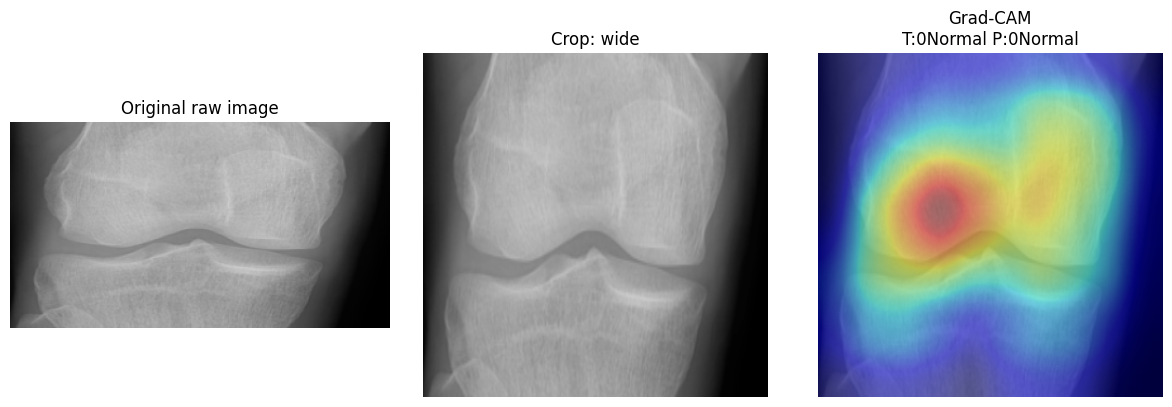

Wrong example index: 3


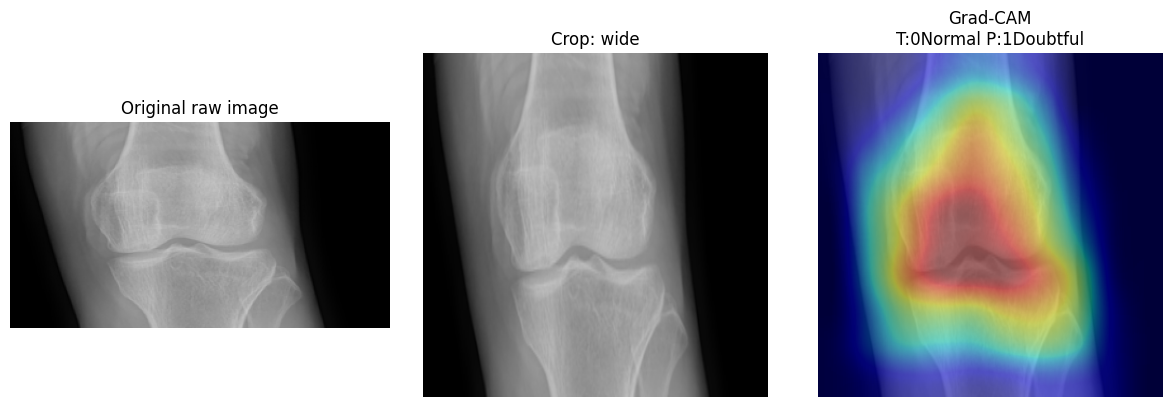

In [22]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_handle = target_layer.register_forward_hook(self._save_activation)
        self.backward_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

    def generate(self, crops, target_class=None, crop_index=0):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)

        logits = self.model(crops)

        if target_class is None:
            target_class = int(logits.argmax(dim=1).item())

        score = logits[:, target_class].sum()
        score.backward()

        # activations shape after flattening crops: [B*N, C, H, W]
        # For B=1, crop_index selects one crop.
        activations = self.activations[crop_index]
        gradients = self.gradients[crop_index]

        weights = gradients.mean(dim=(1, 2))
        cam = torch.sum(weights[:, None, None] * activations, dim=0)
        cam = F.relu(cam)

        cam = cam.detach().cpu().numpy()
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam, target_class

def find_correct_and_wrong_indices(y_true, y_pred):
    correct_idx = None
    wrong_idx = None

    for i, (t, p) in enumerate(zip(y_true, y_pred)):
        if int(t) == int(p) and correct_idx is None:
            correct_idx = i
        if int(t) != int(p) and wrong_idx is None:
            wrong_idx = i
        if correct_idx is not None and wrong_idx is not None:
            break

    return correct_idx, wrong_idx

def show_gradcam_for_index(model, dataset, raw_dataset, idx, y_true, y_pred, crop_index=0):
    crops, label = dataset[idx]
    crops_batch = crops.unsqueeze(0).to(device)

    target_layer = model.backbone.features.denseblock4
    gradcam = GradCAM(model, target_layer)

    cam, pred_class = gradcam.generate(
        crops_batch,
        target_class=int(y_pred[idx]),
        crop_index=crop_index
    )
    gradcam.remove()

    # Image for the selected crop after deterministic valid transform
    crop_img = denormalize_tensor(crops[crop_index])

    # Resize CAM to image size
    cam_img = Image.fromarray(np.uint8(cam * 255)).resize(
        (CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])
    )
    cam_arr = np.array(cam_img) / 255.0

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    raw_path, _ = raw_dataset.samples[idx]
    raw_img = Image.open(raw_path).convert("L")
    plt.imshow(raw_img, cmap="gray", vmin=0, vmax=255)
    plt.title("Original raw image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(crop_img)
    plt.title(f"Crop: {CROP_NAMES[crop_index]}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(crop_img)
    plt.imshow(cam_arr, cmap="jet", alpha=0.45)
    plt.title(
        f"Grad-CAM\nT:{class_names[int(y_true[idx])]} P:{class_names[int(y_pred[idx])]}"
    )
    plt.axis("off")

    plt.tight_layout()
    plt.show()

best_model = build_model()
best_state_dict = torch.load(
    best_result["model_path"],
    map_location=device,
    weights_only=True
)
best_model.load_state_dict(best_state_dict)
best_model.eval()

correct_idx, wrong_idx = find_correct_and_wrong_indices(best_true, best_pred)

print("Correct example index:", correct_idx)
if correct_idx is not None:
    show_gradcam_for_index(
        best_model,
        test_dataset,
        raw_test_dataset,
        correct_idx,
        best_true,
        best_pred,
        crop_index=0
    )

print("Wrong example index:", wrong_idx)
if wrong_idx is not None:
    show_gradcam_for_index(
        best_model,
        test_dataset,
        raw_test_dataset,
        wrong_idx,
        best_true,
        best_pred,
        crop_index=0
    )


## 17. Final Summary

# Experiment Conclusion

This experiment re-evaluates class imbalance handling after moving to a tuned 4-crop multi-region input. The reason is that the best imbalance strategy from the single-image experiment may not remain the best after changing the input representation.

The final method should be selected mainly using validation QWK, while also checking test QWK, MAE, macro F1, and distant errors.


In [23]:
print("=" * 100)
print("Final summary")
print("=" * 100)

display(results_df.sort_values("best_val_qwk", ascending=False))

print("\nSelected by validation QWK:")
print("Method:", best_name)
print("Description:", best_result["description"])
print("Best val QWK:", best_result["best_val_qwk"])
print("Test accuracy:", best_result["test_accuracy"])
print("Test macro F1:", best_result["test_macro_f1"])
print("Test weighted F1:", best_result["test_weighted_f1"])
print("Test QWK:", best_result["test_qwk"])
print("Test MAE:", best_result["test_mae"])
print("Test adjacent errors:", best_result["test_adjacent_errors"])
print("Test distant errors:", best_result["test_distant_errors"])

conclusion = {
    "selected_method": best_name,
    "selected_description": best_result["description"],
    "selection_rule": "highest validation QWK",
    "best_val_qwk": float(best_result["best_val_qwk"]),
    "test_accuracy": float(best_result["test_accuracy"]),
    "test_macro_f1": float(best_result["test_macro_f1"]),
    "test_weighted_f1": float(best_result["test_weighted_f1"]),
    "test_qwk": float(best_result["test_qwk"]),
    "test_mae": float(best_result["test_mae"]),
    "test_total_errors": int(best_result["test_total_errors"]),
    "test_adjacent_errors": int(best_result["test_adjacent_errors"]),
    "test_distant_errors": int(best_result["test_distant_errors"]),
}

with open(RESULTS_DIR / "final_conclusion.json", "w") as f:
    json.dump(conclusion, f, indent=2)

print("\nSaved final_conclusion.json")


Final summary


,experiment,seed,description,use_class_weights,use_sampler,best_epoch,best_val_qwk,model_path,test_accuracy,test_macro_f1,test_weighted_f1,test_qwk,test_mae,test_total_errors,test_adjacent_errors,test_distant_errors,test_loss
3,class_weight,123,Class-weighted HybridChenOrdinalLoss,True,False,20,0.975043,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.840136,0.834930,0.840930,0.911260,0.210884,47,36,11,0.484753
5,class_weight_plus_sampler,123,Class-weighted HybridChenOrdinalLoss + Weighte...,True,True,29,0.973530,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.843537,0.845461,0.844462,0.906794,0.214286,46,33,13,0.498875
10,weighted_random_sampler,3407,HybridChenOrdinalLoss + WeightedRandomSampler,False,True,13,0.964458,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.836735,0.841853,0.838252,0.868184,0.255102,48,29,19,0.457101
2,class_weight_plus_sampler,42,Class-weighted HybridChenOrdinalLoss + Weighte...,True,True,14,0.964091,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.826531,0.828830,0.829133,0.889691,0.241497,51,36,15,0.484865
11,class_weight_plus_sampler,3407,Class-weighted HybridChenOrdinalLoss + Weighte...,True,True,14,0.963600,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.843537,0.849249,0.845030,0.890582,0.231293,46,30,16,0.453092
1,weighted_random_sampler,42,HybridChenOrdinalLoss + WeightedRandomSampler,False,True,30,0.962405,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.850340,0.846344,0.850236,0.908248,0.207483,44,31,13,0.461376
12,class_weight,777,Class-weighted HybridChenOrdinalLoss,True,False,14,0.961858,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.840136,0.831317,0.840126,0.901484,0.217687,47,36,11,0.414003
4,weighted_random_sampler,123,HybridChenOrdinalLoss + WeightedRandomSampler,False,True,13,0.961036,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.826531,0.827653,0.827446,0.911680,0.221088,51,40,11,0.431857
7,weighted_random_sampler,2024,HybridChenOrdinalLoss + WeightedRandomSampler,False,True,13,0.960653,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.846939,0.835772,0.847866,0.875786,0.238095,45,27,18,0.453585
0,class_weight,42,Class-weighted HybridChenOrdinalLoss,True,False,10,0.958654,/kaggle/working/exp07A_tuned_4crop_imbalance_c...,0.836735,0.837593,0.837254,0.889345,0.231293,48,36,12,0.484250



Selected by validation QWK:
Method: class_weight
Description: Class-weighted HybridChenOrdinalLoss
Best val QWK: 0.9750427350427351
Test accuracy: 0.8401360544217688
Test macro F1: 0.8349302331884892
Test weighted F1: 0.8409302232256256
Test QWK: 0.9112602850536966
Test MAE: 0.2108843537414966
Test adjacent errors: 36
Test distant errors: 11

Saved final_conclusion.json


## 18. Save Results

This section saves the main outputs:

- `metrics.json`
- `summary.json`
- `confusion_matrix.png`
- comparison CSV files


In [28]:
summary = {
    "config": CONFIG,
    "crop_names": CROP_NAMES,
    "class_names": class_names,
    "train_class_counts": dict(zip(class_names, train_class_counts.astype(int).tolist())),
    "class_weights": dict(zip(class_names, class_weights_np.astype(float).tolist())),
    "selected_method": best_name,
    "selected_result": best_result,
    "all_results": results_df.to_dict(orient="records"),
}

with open(RESULTS_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

# metrics.json stores selected model metrics only
selected_metrics = {
    "experiment_name": CONFIG["EXPERIMENT_NAME"],
    "selected_method": best_name,
    "selected_description": best_result["description"],
    "test_accuracy": float(best_result["test_accuracy"]),
    "test_macro_f1": float(best_result["test_macro_f1"]),
    "test_weighted_f1": float(best_result["test_weighted_f1"]),
    "test_qwk": float(best_result["test_qwk"]),
    "test_mae": float(best_result["test_mae"]),
    "test_total_errors": int(best_result["test_total_errors"]),
    "test_adjacent_errors": int(best_result["test_adjacent_errors"]),
    "test_distant_errors": int(best_result["test_distant_errors"]),
    "best_val_qwk": float(best_result["best_val_qwk"]),
    "best_epoch": int(best_result["best_epoch"]),
}

with open(RESULTS_DIR / "metrics.json", "w") as f:
    json.dump(selected_metrics, f, indent=2)

print("Saved files to:", RESULTS_DIR)
print("Saved figures to:", FIGURES_DIR)
print("Saved models to:", MODELS_DIR)

print("\nMain files:")
print(RESULTS_DIR / "metrics.json")
print(RESULTS_DIR / "summary.json")
print(FIGURES_DIR / f"confusion_matrix_{best_name}.png")
print(RESULTS_DIR / "imbalance_comparison_results.csv")
print(RESULTS_DIR / "classwise_recall_f1_comparison.csv")
print(RESULTS_DIR / "error_analysis_comparison.csv")

Saved files to: /kaggle/working/7.4crop_imbalance_seed/results
Saved figures to: /kaggle/working/7.4crop_imbalance_seed/figures
Saved models to: /kaggle/working/7.4crop_imbalance_seed/models

Main files:
/kaggle/working/7.4crop_imbalance_seed/results/metrics.json
/kaggle/working/7.4crop_imbalance_seed/results/summary.json
/kaggle/working/7.4crop_imbalance_seed/figures/confusion_matrix_class_weight.png
/kaggle/working/7.4crop_imbalance_seed/results/imbalance_comparison_results.csv
/kaggle/working/7.4crop_imbalance_seed/results/classwise_recall_f1_comparison.csv
/kaggle/working/7.4crop_imbalance_seed/results/error_analysis_comparison.csv
